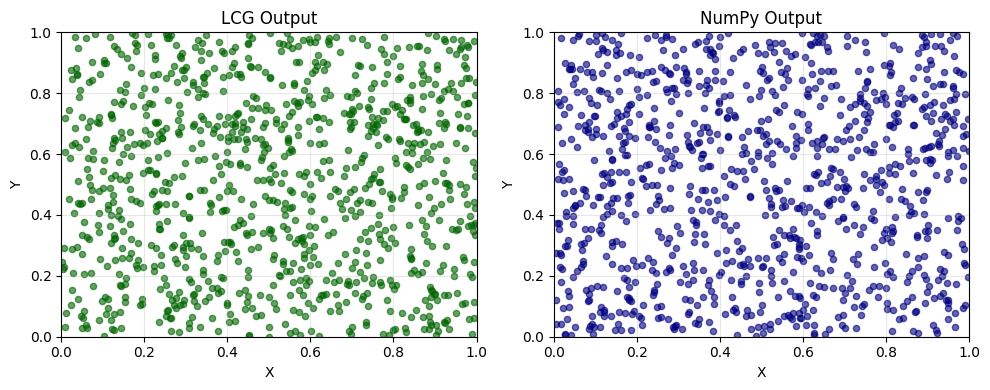

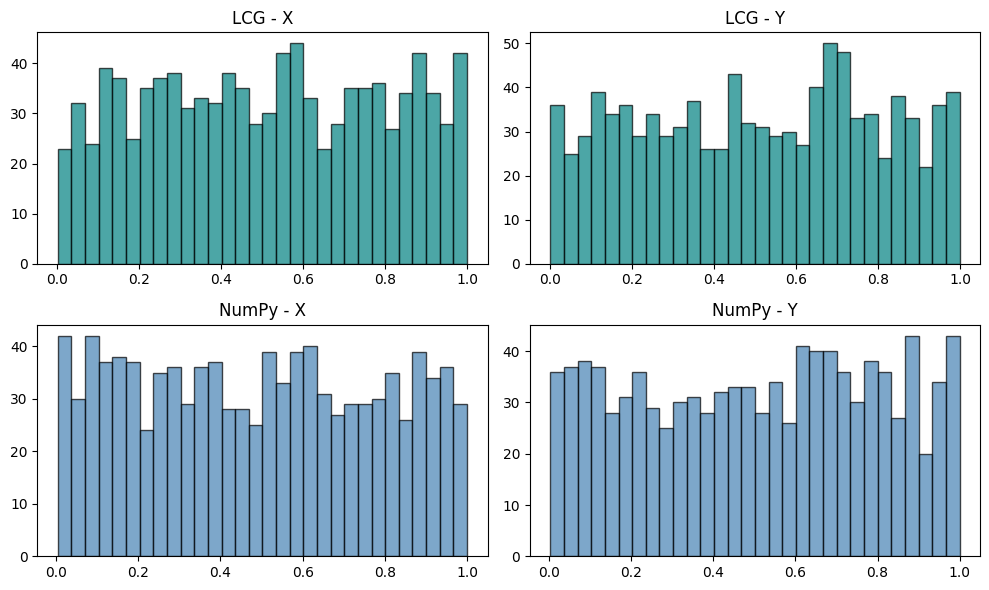

=== Summary Statistics ===
LCG - Mean X: 0.511, Std X: 0.285
LCG - Mean Y: 0.507, Std Y: 0.288
NumPy - Mean X: 0.490, Std X: 0.292
NumPy - Mean Y: 0.507, Std Y: 0.292


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Linear Congruential Generator
class LCG:
    def __init__(self, seed=42, a=1664525, c=1013904223, m=2**32):
        self.x = seed
        self.a, self.c, self.m = a, c, m

    def next(self):
        self.x = (self.a * self.x + self.c) % self.m
        return self.x / self.m

    def generate(self, n):
        return [self.next() for _ in range(n)]

# Generate points
n = 1000
lcg = LCG()
x1, y1 = lcg.generate(n), lcg.generate(n)

np.random.seed(42)
x2, y2 = np.random.rand(n), np.random.rand(n)

# Scatter plots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
titles = ['LCG Output', 'NumPy Output']
data = [(x1, y1, 'darkgreen'), (x2, y2, 'navy')]

for ax, (x, y, color), title in zip(axs, data, titles):
    ax.scatter(x, y, s=20, alpha=0.6, color=color)
    ax.set(title=title, xlim=(0, 1), ylim=(0, 1), xlabel='X', ylabel='Y')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_comparison.pdf')
plt.show()

# Histograms
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
sets = [(x1, 'LCG - X'), (y1, 'LCG - Y'), (x2, 'NumPy - X'), (y2, 'NumPy - Y')]

for ax, (data, title) in zip(axs.ravel(), sets):
    ax.hist(data, bins=30, color='teal' if 'LCG' in title else 'steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('histogram_comparison.pdf')
plt.show()

# Statistics
print("=== Summary Statistics ===")
for name, x, y in [('LCG', x1, y1), ('NumPy', x2, y2)]:
    print(f"{name} - Mean X: {np.mean(x):.3f}, Std X: {np.std(x):.3f}")
    print(f"{name} - Mean Y: {np.mean(y):.3f}, Std Y: {np.std(y):.3f}")
